In [ ]:
#Import libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [4]:
#Create dataset
data = {
    'Age': [18, 25, 28, 35, 40, 50, 60],
    'Income': [20000, 25000, 40000, 60000, 80000, 70000, 50000],
    'Buy': [0, 0, 1, 1, 1, 0, 0]
}

df = pd.DataFrame(data)

print(df)

   Age  Income  Buy
0   18   20000    0
1   25   25000    0
2   28   40000    1
3   35   60000    1
4   40   80000    1
5   50   70000    0
6   60   50000    0


In [ ]:
#Age and Income are input features.
#Buy is the target variable.
#0 means not buying.
#1 means buying#

In [6]:
#Split input and output
X = df[['Age', 'Income']]
y = df['Buy']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [7]:
#Train the Decision Tree model
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


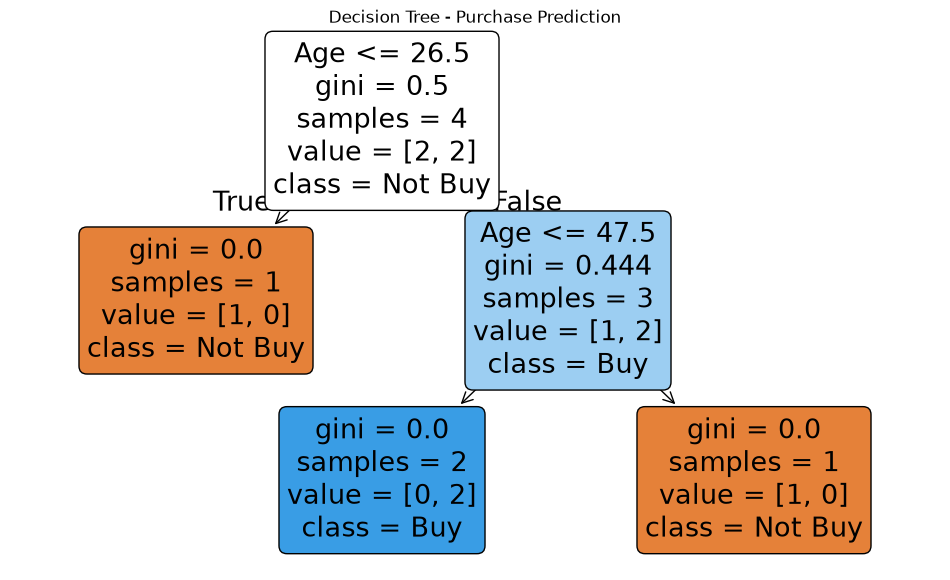

In [8]:
#Visualize the Decision Tree
plt.figure(figsize=(12, 7))

plot_tree(
    model,
    filled=True,
    feature_names=['Age', 'Income'],
    class_names=['Not Buy', 'Buy'],
    rounded=True
)

plt.title("Decision Tree - Purchase Prediction")
plt.show()

In [9]:
#Evaluate the model
y_pred = model.predict(X_test)

print("Actual values:", y_test.values)
print("Predicted values:", y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Actual values: [1 0 0]
Predicted values: [1 0 0]
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [10]:
#Predict for new customer
age = int(input("Enter Age: "))
income = int(input("Enter Income: "))

new_customer = pd.DataFrame({
    'Age': [age],
    'Income': [income]
})

prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Prediction: Customer may buy")
else:
    print("Prediction: Customer may not buy")

Enter Age:  45
Enter Income:  50000


Prediction: Customer may buy
